In [1]:
########################################
#Park and Ratti, 2008, Energy Economics#
#VAR, IRF, and Variance Decomposition###
########################################
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests

In [2]:
####################
## 0. Loading Data #
####################

# Load tab-separated file
data = pd.read_csv('United States.txt', sep='\t')  # Adjust encoding if necessary

# Drop first row if necessary
data = data.iloc[1:].reset_index(drop=True)

# Select variables
y = data[['r', 'op_w', 'ip', 'rsr']].astype(float)

In [3]:
y.head()

,r,op_w,ip,rsr
0,-0.001415,-0.232688,-0.006708,0.071323
1,-0.073454,-0.209715,-0.006886,0.057834
2,-0.079281,-0.097154,0.000782,0.000366
3,0.014742,0.114487,0.002025,0.048671
4,0.009709,-0.165083,-0.003436,0.008129


In [4]:
##################################
## 1. Estimation of VAR(p) Model #
##################################
model = VAR(y)
lag_order = model.select_order(maxlags=12, trend='c')
print(lag_order.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -27.44      -27.38   1.205e-12      -27.42
1       -27.79     -27.48*   8.558e-13     -27.66*
2       -27.76      -27.22   8.752e-13      -27.55
3      -27.84*      -27.06  8.110e-13*      -27.52
4       -27.79      -26.76   8.536e-13      -27.38
5       -27.71      -26.44   9.270e-13      -27.20
6       -27.65      -26.14   9.827e-13      -27.04
7       -27.63      -25.88   1.010e-12      -26.92
8       -27.51      -25.51   1.144e-12      -26.70
9       -27.46      -25.23   1.196e-12      -26.56
10      -27.46      -24.99   1.200e-12      -26.47
11      -27.42      -24.71   1.257e-12      -26.33
12      -27.37      -24.41   1.340e-12      -26.17
--------------------------------------------------


In [5]:
# Fit VAR(3)
model = VAR(y)
results = model.fit(3)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 23, Feb, 2026
Time:                     16:11:32
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -26.9765
Nobs:                     236.000    HQIC:                  -27.4321
Log likelihood:           1985.81    FPE:                8.97386e-13
AIC:                     -27.7397    Det(Omega_mle):     7.24152e-13
--------------------------------------------------------------------
Results for equation r
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const          -0.007308         0.003777           -1.935           0.053
L1.r            0.392473         0.064711            6.065           0.000
L1.op_w         0.056795         0.034041            1.668           0.095
L1.ip        

In [6]:
# Residual serial correlation test
from statsmodels.stats.diagnostic import acorr_ljungbox
resid_df = results.resid

whiteness_test = results.test_whiteness(nlags=12)
print(whiteness_test.summary())

Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 12 is zero. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value  df
-----------------------------------------
         148.4          173.0   0.385 144
-----------------------------------------


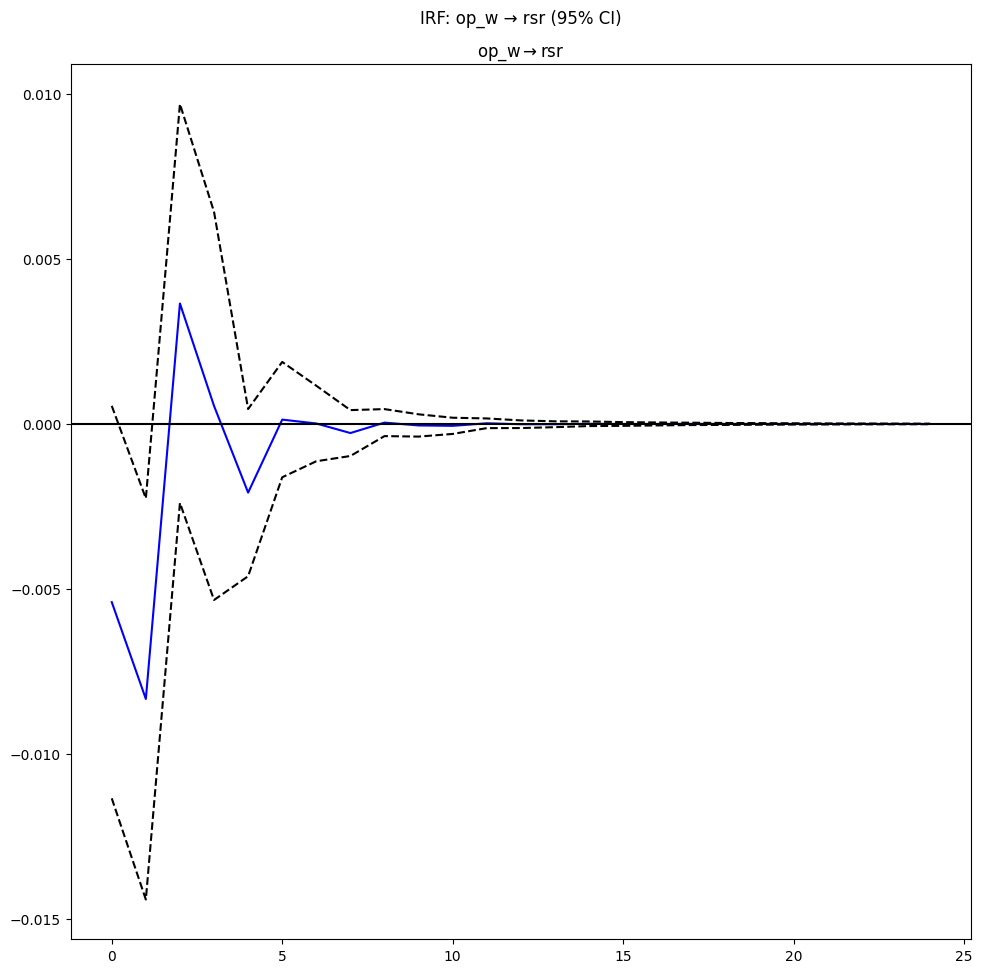

In [7]:
################################
# 2. Impulse-Response Analysis #
################################

# IRF with 95% CI
irf_95 = results.irf(24)
irf_95.plot(orth=True, impulse='op_w', response='rsr')
plt.suptitle("IRF: op_w → rsr (95% CI)")
plt.show()

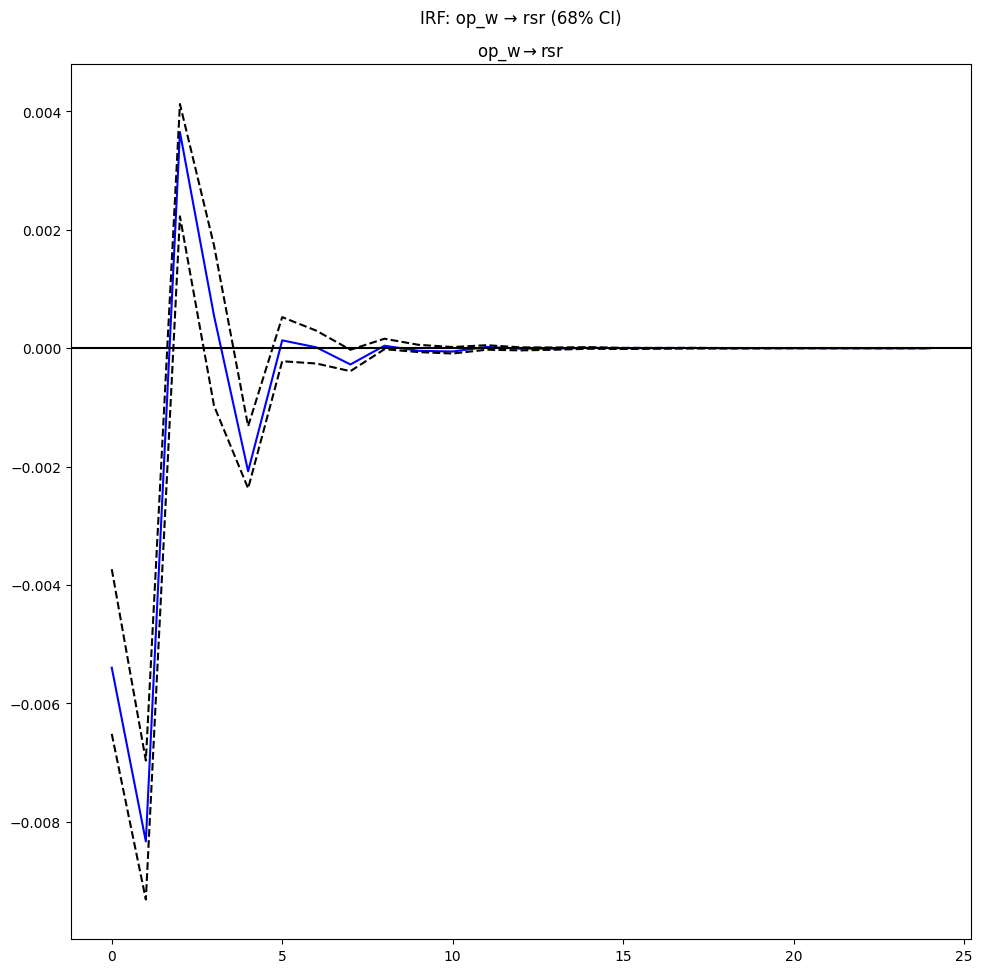

In [8]:
# IRF with 68% CI
irf_68 = results.irf(24)
irf_68.plot(orth=True, impulse='op_w', response='rsr', stderr_type='mc', repl=200, signif=0.68)
plt.suptitle("IRF: op_w → rsr (68% CI)")
plt.show()

In [9]:
############################
# 3.Variance Decomposition #
############################
from numpy.linalg import cholesky

model = VAR(y)
results = model.fit(3)

sigma_u = results.sigma_u
P = cholesky(sigma_u)

irfs_raw = results.irf(24).irfs

irfs = np.array([irfs_raw[h] @ P for h in range(irfs_raw.shape[0])])

n_steps, n_vars = irfs.shape[0], irfs.shape[1]
fevd = np.zeros((n_steps, n_vars, n_vars))

for h in range(n_steps):
    for j in range(n_vars):
        num = np.sum([(irfs[i][j, :]**2) for i in range(h+1)], axis=0)
        denom = np.sum([(irfs[i][j, :]**2).sum() for i in range(h+1)])
        fevd[h, j, :] = num / denom if denom != 0 else np.zeros_like(num)

var_names = results.names
target_idx = var_names.index('rsr')
fevd_rsr = fevd[:, target_idx, :]  # shape: (H, n_vars)

# R 스타일 fevd 출력
fevd_rsr_df = pd.DataFrame(fevd_rsr, columns=var_names)
fevd_rsr_df.index = np.arange(1, len(fevd_rsr_df)+1)
fevd_rsr_df.index.name = 'Horizon'

pd.options.display.float_format = '{:,.7f}'.format
print(fevd_rsr_df.head(24))

                r      op_w        ip       rsr
Horizon                                        
1       0.0000711 0.0133218 0.0180277 0.9685794
2       0.0024547 0.0432834 0.0240039 0.9302580
3       0.0058612 0.0486701 0.0238331 0.9216356
4       0.0061903 0.0487764 0.0238314 0.9212019
5       0.0061821 0.0505162 0.0241781 0.9191236
6       0.0063019 0.0504876 0.0242443 0.9189661
7       0.0063096 0.0504858 0.0242734 0.9189312
8       0.0063099 0.0505126 0.0242816 0.9188960
9       0.0063107 0.0505129 0.0242888 0.9188876
10      0.0063123 0.0505135 0.0242909 0.9188833
11      0.0063131 0.0505146 0.0242909 0.9188813
12      0.0063133 0.0505148 0.0242913 0.9188806
13      0.0063136 0.0505148 0.0242913 0.9188804
14      0.0063137 0.0505148 0.0242915 0.9188801
15      0.0063138 0.0505148 0.0242915 0.9188800
16      0.0063138 0.0505148 0.0242915 0.9188799
17      0.0063138 0.0505148 0.0242916 0.9188798
18      0.0063139 0.0505148 0.0242916 0.9188798
19      0.0063139 0.0505148 0.0242916 0.

In [10]:
############################
# 4.Granger Causality Test #
############################

### Check number of lags (no zero) 3
# H0: rsr does not Granger cause op_w
print("\nGranger Test: rsr → op_w")
grangercausalitytests(y[['op_w', 'rsr']], maxlag=3, verbose=True) # Number of lags = 3


Granger Test: rsr → op_w

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.4891  , p=0.2236  , df_denom=235, df_num=1
ssr based chi2 test:   chi2=1.5081  , p=0.2194  , df=1
likelihood ratio test: chi2=1.5033  , p=0.2202  , df=1
parameter F test:         F=1.4891  , p=0.2236  , df_denom=235, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.1325  , p=0.3240  , df_denom=232, df_num=2
ssr based chi2 test:   chi2=2.3139  , p=0.3144  , df=2
likelihood ratio test: chi2=2.3026  , p=0.3162  , df=2
parameter F test:         F=1.1325  , p=0.3240  , df_denom=232, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.4506  , p=0.0174  , df_denom=229, df_num=3
ssr based chi2 test:   chi2=10.6681 , p=0.0137  , df=3
likelihood ratio test: chi2=10.4340 , p=0.0152  , df=3
parameter F test:         F=3.4506  , p=0.0174  , df_denom=229, df_num=3


c:\Users\A\anaconda3\envs\ts_analysis\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{np.int64(1): ({'ssr_ftest': (np.float64(1.4890736890264087),
    np.float64(0.2235833391529303),
    np.float64(235.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(1.508083140375682),
    np.float64(0.21943181528606154),
    np.int64(1)),
   'lrtest': (np.float64(1.5033252564533086),
    np.float64(0.22016042496993682),
    np.int64(1)),
   'params_ftest': (np.float64(1.489073689026327),
    np.float64(0.2235833391529429),
    np.float64(235.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(1.1325267405900283),
    np.float64(0.32399281405759),
    np.float64(232.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(2.3138692889641095),
    np.float64(0.3144486018045073),
    np.int64(2)),
   'lrtest': (np.float64(2.3026469337764865),
    np.float64(0.31621798828176434),
    np.int64(2)),
   'params_ftest': (np.float64(1.132526740590005),
    np.float64(0.3239928140575975),
    np.float64(232.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
        

In [11]:
# H0: op_w does not Granger cause rsr
print("\nGranger Test: op_w → rsr")
grangercausalitytests(y[['rsr', 'op_w']], maxlag=3, verbose=True) # Number of lags = 3


Granger Test: op_w → rsr

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=6.5843  , p=0.0109  , df_denom=235, df_num=1
ssr based chi2 test:   chi2=6.6684  , p=0.0098  , df=1
likelihood ratio test: chi2=6.5767  , p=0.0103  , df=1
parameter F test:         F=6.5843  , p=0.0109  , df_denom=235, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.1861  , p=0.0164  , df_denom=232, df_num=2
ssr based chi2 test:   chi2=8.5526  , p=0.0139  , df=2
likelihood ratio test: chi2=8.4019  , p=0.0150  , df=2
parameter F test:         F=4.1861  , p=0.0164  , df_denom=232, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.8663  , p=0.0374  , df_denom=229, df_num=3
ssr based chi2 test:   chi2=8.8617  , p=0.0312  , df=3
likelihood ratio test: chi2=8.6993  , p=0.0336  , df=3
parameter F test:         F=2.8663  , p=0.0374  , df_denom=229, df_num=3


{np.int64(1): ({'ssr_ftest': (np.float64(6.584336930284681),
    np.float64(0.010909418547884934),
    np.float64(235.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(6.668392295352145),
    np.float64(0.009813767598610957),
    np.int64(1)),
   'lrtest': (np.float64(6.576682376344252),
    np.float64(0.010332329491881821),
    np.int64(1)),
   'params_ftest': (np.float64(6.584336930284578),
    np.float64(0.010909418547885548),
    np.float64(235.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(4.186070199441467),
    np.float64(0.016369940085524795),
    np.float64(232.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(8.552574459203687),
    np.float64(0.013894152238914893),
    np.int64(2)),
   'lrtest': (np.float64(8.401871774022311),
    np.float64(0.014981549220055033),
    np.int64(2)),
   'params_ftest': (np.float64(4.186070199441451),
    np.float64(0.01636994008552504),
    np.float64(232.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],